Simulated Annealing Plots

In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%load_ext autoreload
%autoreload 2

In [ ]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-21_15-16-36.npy'
brute_force_data_directory = './data/brute_force/first_run' # use same as in cl_optimizer_experiments

In [ ]:
import numpy as np

result_tensor = np.load(results_path)

In [ ]:
result_tensor.shape # should be a 6-tuple: (n_problem_sizes, n_load_factors, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 2)

In [ ]:
loss_tensor = result_tensor[..., 1]
temp_iterations = result_tensor[0, 0, 0, 0, :, 0]

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

extract_candidate_dimension = lambda p: np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_candidates').group(1)))
extract_load_factor = lambda p: float(re.search(string=str(p.name), pattern=r'_(\d*\.\d*)_load_factor').group(1))

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(extract_candidate_dimension(p), extract_load_factor(p), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dim', 'load factor', 'path'])
df = df.groupby(['dim', 'load factor'])['path'].agg(list).reset_index()

In [ ]:
problem_sizes = df['dim'].unique()
load_factors = df['load factor'].unique()
brute_force_data_paths = np.array(df['path'].to_list(), dtype=object).reshape(len(problem_sizes), len(load_factors), -1)

In [ ]:
import pandas as pd
import numpy as np
brute_force_data = np.vectorize(pd.read_csv)(brute_force_data_paths)
loss_spaces = [[np.array([d['loss'] for d in da]) for da in data] for data in brute_force_data] # needs to be list because is inhomogeneous

In [ ]:
# RAAR | Temperature Iterations
# RAAR | Problem Size N
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=3)
raars = np.array([[[[raar(avg, loss_spaces[i][j][k, :]) for avg in avg_loss]for k, avg_loss in enumerate(avg_loss_runs_per_load_factor)] for j, avg_loss_runs_per_load_factor in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])

mean_raars_per_load_factor = raars.mean(axis=(0, 2))
std_raars_per_load_factor = raars.std(axis=(0, 2))

mean_raars = raars.mean(axis=(0, 2)).mean(axis=0) # average over load factor separately
std_raars = raars.std(axis=(0, 2)).mean(axis=0)

mean_raars_per_problem_size_and_load_factor = raars.mean(axis=(2, 3))
std_raars_per_problem_size_and_load_factor = raars.std(axis=(2, 3))

mean_raars_per_problem_size = raars.mean(axis=(2, 3)).mean(axis=1) # average over load factor separately
std_raars_per_problem_size = raars.std(axis=(2, 3)).mean(axis=1)

In [ ]:
# Find optimal candidates to calculate TTS*
min_losses = np.array([[s.min(axis=1) for s in spaces] for spaces in loss_spaces])
optimal_candidates_found = np.count_nonzero(loss_tensor ==  np.expand_dims(np.expand_dims(min_losses, axis=-1), axis=-1), axis=3)
p_star = optimal_candidates_found / loss_tensor.shape[-2] # probability of finding optimal candidate

In [ ]:
# TTS* | Problem Size N
from metrics import min_tts
tts_min = min_tts(p_star)

avg_min_tts_per_load_factor = tts_min.mean(axis=2)
std_min_tts_per_load_factor = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=2)

avg_min_tts = tts_min.mean(axis=-1).mean(axis=1) # average over load factor separately
std_min_tts = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=-1).mean(axis=1)

In [ ]:
avg_min_tts_per_load_factor.shape

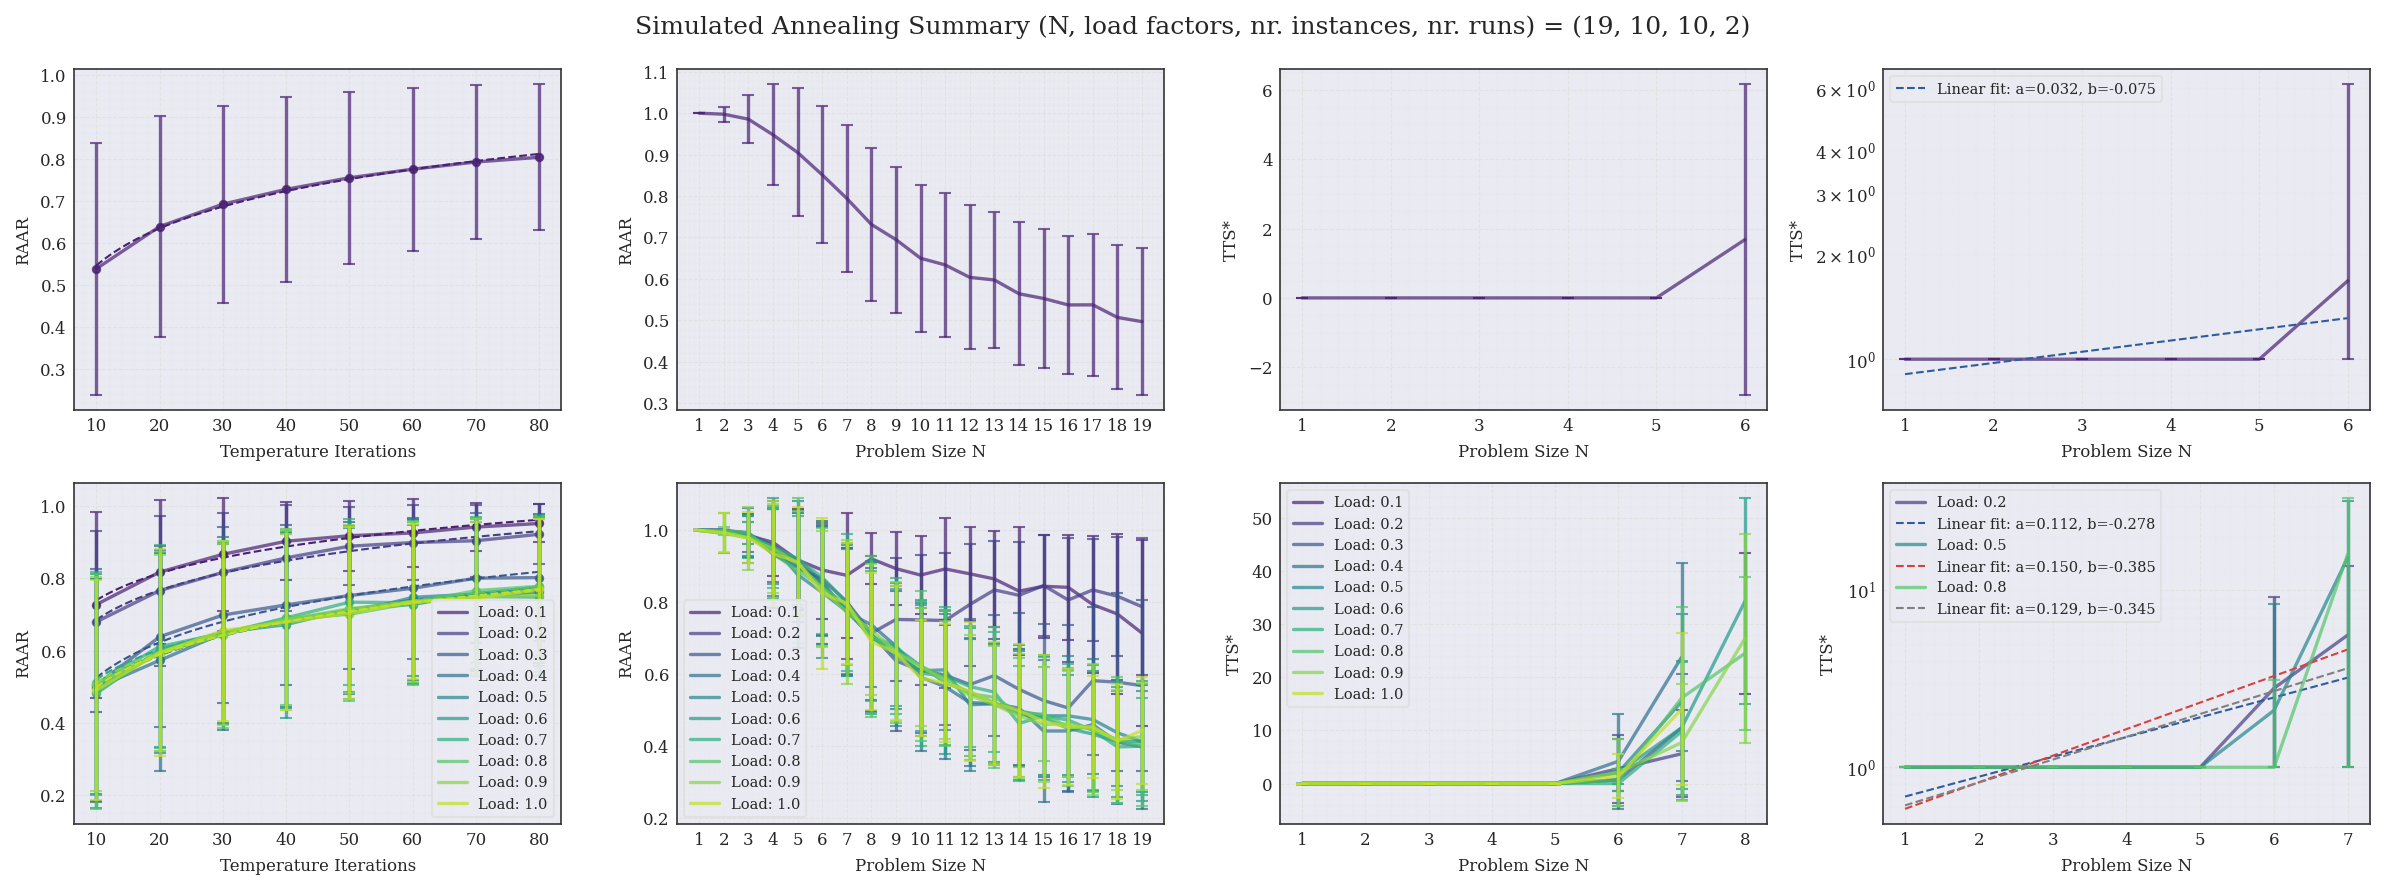

In [72]:
from plotting import plot_per_load_factor, plot_with_errorbar, log_plot_per_load_factor_with_fits, log_plot_with_fits
from datetime import datetime
import styling
import seaborn as sns

styling.set_my_style(use_latex=False)

palette = sns.color_palette("viridis", len(load_factors))


fig, ax = styling.subplots(2, 4, figsize=(16, 6))

fig.suptitle(f'Simulated Annealing Summary (N, load factors, nr. instances, nr. runs) = {loss_tensor.shape[0], loss_tensor.shape[1], loss_tensor.shape[2], loss_tensor.shape[3]}')

plot_with_errorbar(ax=ax[0, 0], xs=temp_iterations, means=mean_raars, stds=std_raars, labels=('RAAR', 'Temperature Iterations'), color=palette[0], regplot='log')
plot_with_errorbar(ax=ax[0, 1], xs=problem_sizes, means=mean_raars_per_problem_size, stds=std_raars_per_problem_size, labels=('RAAR', 'Problem Size N'), color=palette[0], set_xticks=True)
plot_with_errorbar(ax=ax[0, 2], xs=problem_sizes, means=avg_min_tts, stds=std_min_tts, labels=('TTS*', 'Problem Size N'), color=palette[0], set_xticks=True)
log_plot_with_fits(ax=ax[0, 3], xs=problem_sizes, means=avg_min_tts, stds=std_min_tts, labels=('TTS*', 'Problem Size N'), palette=palette, set_xticks=True)

plot_per_load_factor(
    ax=ax[1, 0],
    xs=temp_iterations,
    means=mean_raars_per_load_factor,
    stds=std_raars_per_load_factor,
    load_factors=load_factors,
    labels=("RAAR", 'Temperature Iterations'),
    palette=palette,
    regplot='log'
)
plot_per_load_factor(
    ax=ax[1, 1],
    xs=problem_sizes,
    means=mean_raars_per_problem_size_and_load_factor.T,
    stds=std_raars_per_problem_size_and_load_factor.T,
    load_factors=load_factors,
    labels=("RAAR", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
plot_per_load_factor(
    ax=ax[1, 2],
    xs=problem_sizes,
    means=avg_min_tts_per_load_factor.T,
    stds=std_min_tts_per_load_factor.T,
    load_factors=load_factors,
    labels=("TTS*", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
log_plot_per_load_factor_with_fits(
    ax=ax[1, 3],
    xs=problem_sizes,
    means=avg_min_tts_per_load_factor.T[1::3, :],
    stds=std_min_tts_per_load_factor.T[1::3, :],
    load_factors=load_factors[1::3],
    labels=("TTS*", 'Problem Size N'),
    palette=palette[1::3],
    set_xticks=True,
)

file_name = f'simulated_annealing_performance_summary_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png'
plt.tight_layout()
plt.savefig(f'./plots/{file_name}')

In [73]:
print(f"Saved Plot to: plots/{file_name}")

Saved Plot to: plots/simulated_annealing_performance_summary_20260423-182109.png
